<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/B25CM1027_KARTIK_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# Q1: Data Loading & Feature Analysis

# Load datasets
iris = load_iris()
wine = load_wine()

# Store datasets
datasets = {
    "Iris": iris,
    "Wine": wine
}

# Function to display dataset information
def analyze_dataset(name, data):
    X = data.data
    y = data.target

    print(f"\n{'='*50}")
    print(f"{name} Dataset")
    print(f"{'='*50}")

    print("Shape:", X.shape)

    print("\nFeature ranges (min - max):")
    for i, feature_name in enumerate(data.feature_names):
        print(
            f"{feature_name}: "
            f"{X[:, i].min():.2f} - {X[:, i].max():.2f}"
        )

    print("\nClass distribution:")
    classes, counts = np.unique(y, return_counts=True)

    for class_label, count in zip(classes, counts):
        print(f"Class {class_label}: {count}")


# Analyze both datasets
for name, data in datasets.items():
    analyze_dataset(name, data)


# Split both datasets into 75% training and 25% testing
X_iris, X_iris_test, y_iris, y_iris_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.25,
    stratify=iris.target,
    random_state=42
)

X_wine, X_wine_test, y_wine, y_wine_test = train_test_split(
    wine.data,
    wine.target,
    test_size=0.25,
    stratify=wine.target,
    random_state=42
)

print("\n" + "="*50)
print("Train-Test Split")
print("="*50)

print("Iris training shape:", X_iris.shape)
print("Iris testing shape:", X_iris_test.shape)

print("Wine training shape:", X_wine.shape)
print("Wine testing shape:", X_wine_test.shape)


Iris Dataset
Shape: (150, 4)

Feature ranges (min - max):
sepal length (cm): 4.30 - 7.90
sepal width (cm): 2.00 - 4.40
petal length (cm): 1.00 - 6.90
petal width (cm): 0.10 - 2.50

Class distribution:
Class 0: 50
Class 1: 50
Class 2: 50

Wine Dataset
Shape: (178, 13)

Feature ranges (min - max):
alcohol: 11.03 - 14.83
malic_acid: 0.74 - 5.80
ash: 1.36 - 3.23
alcalinity_of_ash: 10.60 - 30.00
magnesium: 70.00 - 162.00
total_phenols: 0.98 - 3.88
flavanoids: 0.34 - 5.08
nonflavanoid_phenols: 0.13 - 0.66
proanthocyanins: 0.41 - 3.58
color_intensity: 1.28 - 13.00
hue: 0.48 - 1.71
od280/od315_of_diluted_wines: 1.27 - 4.00
proline: 278.00 - 1680.00

Class distribution:
Class 0: 59
Class 1: 71
Class 2: 48

Train-Test Split
Iris training shape: (112, 4)
Iris testing shape: (38, 4)
Wine training shape: (133, 13)
Wine testing shape: (45, 13)


## Q1: Data Loading & Feature Analysis

The Iris dataset contains 150 samples, 4 features, and 3 classes. The Wine dataset contains 178 samples, 13 features, and 3 classes.

The feature ranges are different because the features represent different measurements and therefore use different units and scales. For example, in the Wine dataset, some features have values close to 1 while another feature can have values up to around 1680.

This difference is important for KNN because KNN uses distances between data points to find the nearest neighbors. Features with much larger numerical ranges can dominate the distance calculation and have more influence than features with smaller ranges.

Therefore, feature scaling is important before applying KNN so that features contribute more fairly to the distance calculation.

Both datasets were split into 75% training data and 25% testing data using stratification and random_state=42. Stratification helps maintain approximately the same class distribution in the training and testing sets.

In [3]:
# Q2: Feature Scaling Strategies

# Create scalers
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

# Store the datasets and their train-test splits
dataset_splits = {
    "Iris": (X_iris, X_iris_test),
    "Wine": (X_wine, X_wine_test)
}

# Store scaled data for use in later questions
scaled_data = {}

# Store summary results
scaling_results = []

for dataset_name, (X_train, X_test) in dataset_splits.items():

    scaled_data[dataset_name] = {}

    for scaler_name, scaler in scalers.items():

        # Fit ONLY on training data
        X_train_scaled = scaler.fit_transform(X_train)

        # Transform test data using the same fitted scaler
        X_test_scaled = scaler.transform(X_test)

        # Save scaled datasets
        scaled_data[dataset_name][scaler_name] = {
            "X_train": X_train_scaled,
            "X_test": X_test_scaled
        }

        # Calculate statistics
        scaling_results.append({
            "Dataset": dataset_name,
            "Scaler": scaler_name,
            "Train Mean": X_train_scaled.mean(),
            "Train Std": X_train_scaled.std(),
            "Train Min": X_train_scaled.min(),
            "Train Max": X_train_scaled.max(),
            "Test Mean": X_test_scaled.mean(),
            "Test Std": X_test_scaled.std(),
            "Test Min": X_test_scaled.min(),
            "Test Max": X_test_scaled.max()
        })

# Create comparison table
scaling_comparison = pd.DataFrame(scaling_results)

print("Scaling Comparison Table:")
display(scaling_comparison.round(4))

Scaling Comparison Table:


,Dataset,Scaler,Train Mean,Train Std,Train Min,Train Max,Test Mean,Test Std,Test Min,Test Max
0,Iris,StandardScaler,-0.0000,1.0000,-2.4136,3.0200,-0.0557,0.9353,-1.7396,2.1144
1,Iris,MinMaxScaler,0.4494,0.2672,0.0000,1.0000,0.4376,0.2528,-0.0172,0.9583
2,Wine,StandardScaler,0.0000,1.0000,-3.7930,4.1539,0.0233,1.0468,-2.5133,3.2454
3,Wine,MinMaxScaler,0.4242,0.2248,0.0000,1.0000,0.4312,0.2405,-0.0032,1.3941


In [4]:
# Detailed statistics for each dataset and scaler

for dataset_name in scaled_data:

    print("\n" + "="*60)
    print(f"{dataset_name} Dataset")
    print("="*60)

    for scaler_name in scaled_data[dataset_name]:

        X_train_scaled = scaled_data[dataset_name][scaler_name]["X_train"]
        X_test_scaled = scaled_data[dataset_name][scaler_name]["X_test"]

        print(f"\n{scaler_name}")

        print("Training data:")
        print("Mean:", np.round(X_train_scaled.mean(axis=0), 4))
        print("Std :", np.round(X_train_scaled.std(axis=0), 4))
        print("Min :", np.round(X_train_scaled.min(axis=0), 4))
        print("Max :", np.round(X_train_scaled.max(axis=0), 4))

        print("\nTesting data:")
        print("Mean:", np.round(X_test_scaled.mean(axis=0), 4))
        print("Std :", np.round(X_test_scaled.std(axis=0), 4))
        print("Min :", np.round(X_test_scaled.min(axis=0), 4))
        print("Max :", np.round(X_test_scaled.max(axis=0), 4))


Iris Dataset

StandardScaler
Training data:
Mean: [-0. -0. -0. -0.]
Std : [1. 1. 1. 1.]
Min : [-1.8573 -2.4136 -1.5004 -1.4263]
Max : [2.3808 3.02   1.7658 1.7034]

Testing data:
Mean: [-0.1596 -0.0781 -0.014   0.0287]
Std : [0.8717 0.9307 0.963  0.9622]
Min : [-1.7396 -1.7344 -1.5567 -1.2959]
Max : [1.6744 2.1144 1.428  1.573 ]

MinMaxScaler
Training data:
Mean: [0.4382 0.4442 0.4594 0.4557]
Std : [0.236  0.184  0.3062 0.3195]
Min : [0. 0. 0. 0.]
Max : [1. 1. 1. 1.]

Testing data:
Mean: [0.4006 0.4298 0.4551 0.4649]
Std : [0.2057 0.1713 0.2948 0.3075]
Min : [ 0.0278  0.125  -0.0172  0.0417]
Max : [0.8333 0.8333 0.8966 0.9583]

Wine Dataset

StandardScaler
Training data:
Mean: [ 0.  0.  0.  0.  0.  0. -0. -0.  0. -0.  0.  0. -0.]
Std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min : [-2.4262 -1.4666 -3.793  -2.7139 -2.0099 -2.0752 -1.7321 -1.9598 -2.0295
 -1.5818 -2.0876 -1.9402 -1.5453]
Max : [2.3304 3.192  3.2077 3.0708 4.1539 2.5453 1.8298 2.2743 3.3843 3.3912
 3.3787 1.941  2.527 ]

## Q2: Feature Scaling Strategies

StandardScaler and MinMaxScaler are two methods used to put features on comparable scales.

StandardScaler standardizes each feature by subtracting its mean and dividing by its standard deviation. Therefore, the training features generally have a mean close to 0 and a standard deviation close to 1.

MinMaxScaler transforms each feature to a specified range, which is [0, 1] by default. The minimum value of a training feature becomes 0 and the maximum becomes 1.

The scaler must be fitted only on the training data. If the scaler is fitted using both training and testing data, information from the test set can leak into the training process. This can make the evaluation unreliable.

Scaling is particularly important for KNN because KNN uses distances to determine which observations are nearest. Without scaling, a feature with a much larger numerical range can dominate the distance calculation.

Therefore, the correct procedure is:

1. Split the data into training and testing sets.
2. Fit the scaler using only the training data.
3. Transform the training data.
4. Transform the testing data using the same fitted scaler.

In [5]:
# Q3: Distance Metrics Comparison

# Get StandardScaler Iris data from Q2
X_iris_train_scaled = scaled_data["Iris"]["StandardScaler"]["X_train"]
X_iris_test_scaled = scaled_data["Iris"]["StandardScaler"]["X_test"]

# Define distance metrics
distance_metrics = ["euclidean", "manhattan"]

# Store results
distance_results = []

for metric in distance_metrics:

    # Create KNN model with k=5
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    # Train the model
    knn.fit(X_iris_train_scaled, y_iris)

    # Predictions
    y_train_pred = knn.predict(X_iris_train_scaled)
    y_test_pred = knn.predict(X_iris_test_scaled)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_iris, y_train_pred)
    test_accuracy = accuracy_score(y_iris_test, y_test_pred)

    # Store results
    distance_results.append({
        "Distance Metric": metric,
        "Training Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

# Create comparison table
distance_comparison = pd.DataFrame(distance_results)

print("Distance Metrics Comparison:")
display(distance_comparison.round(4))

Distance Metrics Comparison:


,Distance Metric,Training Accuracy,Test Accuracy
0,euclidean,0.9821,0.9211
1,manhattan,0.9643,0.9211


## Q3: Distance Metrics Comparison

The Iris dataset was standardized using StandardScaler and KNN was trained with k=5 using two different distance metrics: Euclidean and Manhattan.

Euclidean distance measures the straight-line distance between two points, while Manhattan distance measures distance by summing the absolute differences between their feature values.

For this train-test split, Euclidean distance achieved a training accuracy of approximately 98.21% and test accuracy of approximately 92.11%. Manhattan distance achieved a training accuracy of approximately 96.43% and test accuracy of approximately 92.11%.

Both distance metrics produced the same test accuracy in this experiment. Therefore, there is no significant difference in test performance for this particular split.

The difference in training accuracy shows that the choice of distance metric can affect how KNN fits the training data, but in this experiment it did not change the final test accuracy.

In [6]:
# Q4: Trade-off with k Values

# Get StandardScaler Iris data
X_iris_train_scaled = scaled_data["Iris"]["StandardScaler"]["X_train"]
X_iris_test_scaled = scaled_data["Iris"]["StandardScaler"]["X_test"]

# Values of k required by the assignment
k_values = [1, 3, 5, 7, 9, 15]

# Store results
k_results = []

for k in k_values:

    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn.fit(X_iris_train_scaled, y_iris)

    # Predictions
    y_train_pred = knn.predict(X_iris_train_scaled)
    y_test_pred = knn.predict(X_iris_test_scaled)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_iris, y_train_pred)
    test_accuracy = accuracy_score(y_iris_test, y_test_pred)

    # Store results
    k_results.append({
        "k": k,
        "Training Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

# Create results table
k_comparison = pd.DataFrame(k_results)

print("KNN Performance for Different k Values:")
display(k_comparison.round(4))

KNN Performance for Different k Values:


,k,Training Accuracy,Test Accuracy
0,1,1.0000,0.9474
1,3,0.9643,0.9211
2,5,0.9821,0.9211
3,7,0.9732,0.9474
4,9,0.9643,0.9737
5,15,0.9732,0.9737


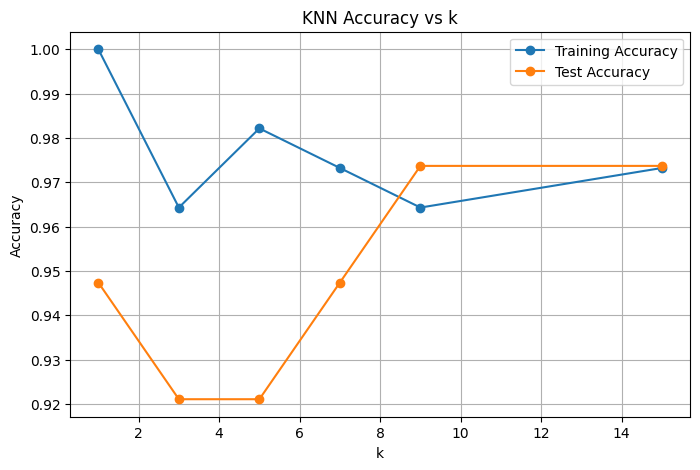

In [7]:
# Plot training vs testing accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    k_comparison["k"],
    k_comparison["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    k_comparison["k"],
    k_comparison["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.legend()
plt.grid(True)
plt.show()

## Q4: Trade-off with k Values

The KNN model was trained using k values of 1, 3, 5, 7, 9, and 15.

When k=1, the model gives very high training accuracy because each training point is essentially its own nearest neighbor. This can cause overfitting because the model becomes too sensitive to individual training samples.

As k increases, the model considers more neighboring points when making a prediction. This makes the decision boundary smoother and reduces sensitivity to individual observations.

However, if k becomes too large, the model can become too simple and may start underfitting because local patterns are averaged out.

For this experiment, k=1 shows the strongest sign of overfitting because the training accuracy is 100% while the test accuracy is lower. The model becomes more balanced at larger k values, where the difference between training and testing accuracy is smaller.

The best value of k should be selected based on performance on unseen data rather than only training accuracy.

In [8]:
# Q5: Curse of Dimensionality

from sklearn.neighbors import NearestNeighbors

# Get StandardScaler data
X_iris_train_scaled = scaled_data["Iris"]["StandardScaler"]["X_train"]
X_iris_test_scaled = scaled_data["Iris"]["StandardScaler"]["X_test"]

X_wine_train_scaled = scaled_data["Wine"]["StandardScaler"]["X_train"]
X_wine_test_scaled = scaled_data["Wine"]["StandardScaler"]["X_test"]


# ---------------------------------------------------------
# Calculate average distance to 5 nearest training neighbors
# ---------------------------------------------------------

# Iris
iris_neighbors = NearestNeighbors(n_neighbors=5)
iris_neighbors.fit(X_iris_train_scaled)

iris_distances, iris_indices = iris_neighbors.kneighbors(
    X_iris_test_scaled
)

iris_average_distance = iris_distances.mean()


# Wine
wine_neighbors = NearestNeighbors(n_neighbors=5)
wine_neighbors.fit(X_wine_train_scaled)

wine_distances, wine_indices = wine_neighbors.kneighbors(
    X_wine_test_scaled
)

wine_average_distance = wine_distances.mean()


# Display average distances
distance_comparison = pd.DataFrame({
    "Dataset": ["Iris", "Wine"],
    "Number of Features": [
        X_iris_train_scaled.shape[1],
        X_wine_train_scaled.shape[1]
    ],
    "Average Distance to 5 Nearest Neighbors": [
        iris_average_distance,
        wine_average_distance
    ]
})

print("Average Distance Comparison:")
display(distance_comparison.round(4))


# ---------------------------------------------------------
# Train KNN on Wine for k = 3 to 15
# ---------------------------------------------------------

wine_k_values = list(range(3, 16))

wine_accuracy_results = []

for k in wine_k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_wine_train_scaled, y_wine)

    y_wine_pred = knn.predict(X_wine_test_scaled)

    test_accuracy = accuracy_score(
        y_wine_test,
        y_wine_pred
    )

    wine_accuracy_results.append({
        "k": k,
        "Test Accuracy": test_accuracy
    })


# Create results table
wine_k_comparison = pd.DataFrame(wine_accuracy_results)

print("\nWine KNN Accuracy for Different k Values:")
display(wine_k_comparison.round(4))

Average Distance Comparison:


,Dataset,Number of Features,Average Distance to 5 Nearest Neighbors
0,Iris,4,0.5236
1,Wine,13,2.3124



Wine KNN Accuracy for Different k Values:


,k,Test Accuracy
0,3,0.9556
1,4,0.9333
2,5,0.9333
3,6,0.9333
4,7,0.9778
5,8,0.9556
6,9,0.9778
7,10,0.9778
8,11,0.9778
9,12,0.9778


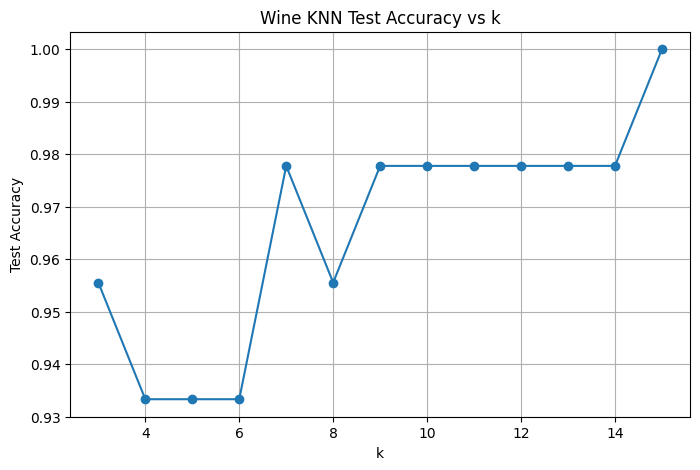

In [9]:
# Plot Wine test accuracy vs k

plt.figure(figsize=(8, 5))

plt.plot(
    wine_k_comparison["k"],
    wine_k_comparison["Test Accuracy"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Wine KNN Test Accuracy vs k")
plt.grid(True)

plt.show()

## Q5: Curse of Dimensionality

The average distance to the 5 nearest training neighbors was calculated for both Iris and Wine after StandardScaler preprocessing.

Wine has 13 features, while Iris has only 4 features. The Wine dataset has a larger average distance between samples and their nearest neighbors in this experiment.

The curse of dimensionality refers to the problem that occurs when the number of features becomes large. As the number of dimensions increases, data points tend to become more spread out and distances between points become less informative.

This is particularly important for KNN because KNN depends directly on distances to identify neighboring observations. In high-dimensional data, the difference between near and far points can become less meaningful.

In this experiment, Wine has more features and therefore shows the effect of higher dimensionality. However, having more dimensions does not automatically mean that Wine is harder to classify. Classification difficulty should be determined from the actual model performance and test accuracy rather than from dimensionality alone.

In [10]:
# Q6: Cross-Validation & Model Selection

from sklearn.pipeline import Pipeline

# Wine data from Q1
X_wine_train_raw = X_wine
X_wine_test_raw = X_wine_test

# k values required by the assignment
cv_k_values = [3, 5, 7, 9, 11]

# 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store results
cv_results_list = []

for k in cv_k_values:

    # Pipeline: scaling is fitted separately inside each CV fold
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    # Cross-validation scores
    cv_scores = cross_val_score(
        model,
        X_wine_train_raw,
        y_wine,
        cv=cv,
        scoring="accuracy"
    )

    # Fit on the complete training set
    model.fit(X_wine_train_raw, y_wine)

    # Test-set accuracy
    y_test_pred = model.predict(X_wine_test_raw)
    test_accuracy = accuracy_score(y_wine_test, y_test_pred)

    # Store results
    cv_results_list.append({
        "k": k,
        "Mean CV Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Single Test Accuracy": test_accuracy
    })

# Create comparison table
cv_results = pd.DataFrame(cv_results_list)

print("Cross-Validation Results:")
display(cv_results.round(4))

Cross-Validation Results:


,k,Mean CV Accuracy,CV Std,Single Test Accuracy
0,3,0.9621,0.0243,0.9556
1,5,0.9470,0.0390,0.9333
2,7,0.9618,0.0344,0.9778
3,9,0.9541,0.0449,0.9778
4,11,0.9695,0.0287,0.9778


In [11]:
# Find the best k according to mean CV accuracy

best_k = cv_results.loc[
    cv_results["Mean CV Accuracy"].idxmax(),
    "k"
]

best_cv_accuracy = cv_results["Mean CV Accuracy"].max()

print("Best k according to Cross-Validation:", best_k)
print("Best Mean CV Accuracy:", round(best_cv_accuracy, 4))

# Find best k from the single test split
best_test_k = cv_results.loc[
    cv_results["Single Test Accuracy"].idxmax(),
    "k"
]

best_test_accuracy = cv_results["Single Test Accuracy"].max()

print("\nBest k according to Single Test Split:", best_test_k)
print("Best Single Test Accuracy:", round(best_test_accuracy, 4))

Best k according to Cross-Validation: 11
Best Mean CV Accuracy: 0.9695

Best k according to Single Test Split: 7
Best Single Test Accuracy: 0.9778


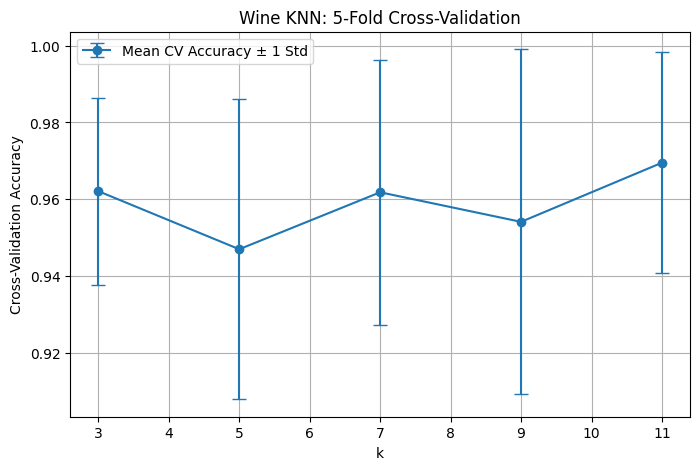

In [12]:
# Plot mean CV accuracy with ±1 standard deviation

plt.figure(figsize=(8, 5))

plt.errorbar(
    cv_results["k"],
    cv_results["Mean CV Accuracy"],
    yerr=cv_results["CV Std"],
    marker="o",
    capsize=5,
    label="Mean CV Accuracy ± 1 Std"
)

plt.xlabel("k")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Wine KNN: 5-Fold Cross-Validation")
plt.grid(True)
plt.legend()

plt.show()

In [13]:
# Compare uniform and distance-weighted KNN
# using the best k from cross-validation

best_models = {
    "Uniform": KNeighborsClassifier(
        n_neighbors=best_k,
        weights="uniform"
    ),
    "Distance Weighted": KNeighborsClassifier(
        n_neighbors=best_k,
        weights="distance"
    )
}

weighting_results = []
confusion_matrices = {}

# Use already scaled Wine training and testing data
X_wine_train_scaled = scaled_data["Wine"]["StandardScaler"]["X_train"]
X_wine_test_scaled = scaled_data["Wine"]["StandardScaler"]["X_test"]

for weighting_name, model in best_models.items():

    model.fit(X_wine_train_scaled, y_wine)

    y_pred = model.predict(X_wine_test_scaled)

    accuracy = accuracy_score(
        y_wine_test,
        y_pred
    )

    cm = confusion_matrix(
        y_wine_test,
        y_pred
    )

    weighting_results.append({
        "Weighting": weighting_name,
        "k": best_k,
        "Test Accuracy": accuracy
    })

    confusion_matrices[weighting_name] = cm

# Display comparison
weighting_comparison = pd.DataFrame(weighting_results)

print("Uniform vs Distance-Weighted KNN:")
display(weighting_comparison.round(4))

Uniform vs Distance-Weighted KNN:


,Weighting,k,Test Accuracy
0,Uniform,11,0.9778
1,Distance Weighted,11,0.9778


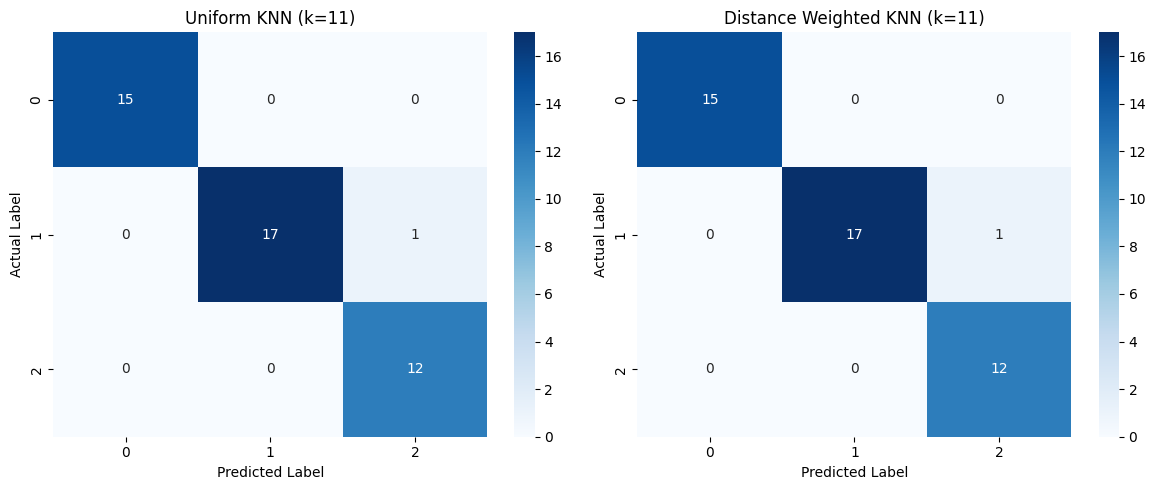

In [14]:
# Plot confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (weighting_name, cm) in zip(
    axes,
    confusion_matrices.items()
):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(
        f"{weighting_name} KNN (k={best_k})"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

## Q6: Cross-Validation & Model Selection

Five-fold cross-validation was used to evaluate different values of k for the Wine dataset.

In 5-fold cross-validation, the training data is divided into five folds. In each iteration, four folds are used for training and one fold is used for validation. This process is repeated five times so that every fold is used as the validation set once.

The mean CV accuracy represents the average performance across the five folds. The CV standard deviation shows how much the performance changes between the folds.

Cross-validation is generally more reliable than relying on a single train-test split because the model is evaluated on multiple different validation sets instead of depending on only one split.

The best k from cross-validation is selected using the highest mean CV accuracy. The best k from the single test split is selected separately using test accuracy. These values may or may not be the same because a single test split can give a different result from the average performance across multiple folds.

The comparison between uniform and distance-weighted KNN shows whether giving closer neighbors more influence improves performance. Uniform weighting gives all neighbors equal importance, while distance weighting gives greater importance to closer neighbors.

If the two methods have the same accuracy, distance weighting did not provide an improvement for this particular dataset and split.

In [15]:
# Q7: KNN Regression - Scaling Impact

# Load Diabetes dataset
diabetes = load_diabetes()

X_diabetes = diabetes.data
y_diabetes = diabetes.target

# Display basic information
print("Diabetes Dataset Shape:", X_diabetes.shape)

print("\nFeature Ranges:")
for i, feature_name in enumerate(diabetes.feature_names):
    print(
        f"{feature_name}: "
        f"{X_diabetes[:, i].min():.4f} - "
        f"{X_diabetes[:, i].max():.4f}"
    )

Diabetes Dataset Shape: (442, 10)

Feature Ranges:
age: -0.1072 - 0.1107
sex: -0.0446 - 0.0507
bmi: -0.0903 - 0.1706
bp: -0.1124 - 0.1320
s1: -0.1268 - 0.1539
s2: -0.1156 - 0.1988
s3: -0.1023 - 0.1812
s4: -0.0764 - 0.1852
s5: -0.1261 - 0.1336
s6: -0.1378 - 0.1356


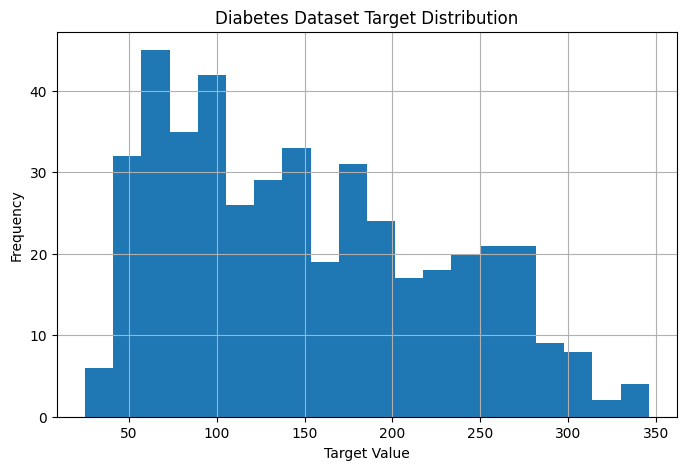

In [16]:
# Plot target distribution

plt.figure(figsize=(8, 5))

plt.hist(y_diabetes, bins=20)

plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.title("Diabetes Dataset Target Distribution")
plt.grid(True)

plt.show()

In [17]:
# Split Diabetes dataset into training and testing data

X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.25,
    random_state=42
)

print("Training shape:", X_diabetes_train.shape)
print("Testing shape:", X_diabetes_test.shape)

Training shape: (331, 10)
Testing shape: (111, 10)


In [18]:
# Train KNN Regressor with three scaling strategies

# ---------------------------------------------------------
# 1. Unscaled
# ---------------------------------------------------------

knn_unscaled = KNeighborsRegressor(n_neighbors=5)

knn_unscaled.fit(
    X_diabetes_train,
    y_diabetes_train
)

y_pred_unscaled = knn_unscaled.predict(
    X_diabetes_test
)


# ---------------------------------------------------------
# 2. StandardScaler
# ---------------------------------------------------------

standard_scaler = StandardScaler()

X_diabetes_train_standard = standard_scaler.fit_transform(
    X_diabetes_train
)

X_diabetes_test_standard = standard_scaler.transform(
    X_diabetes_test
)

knn_standard = KNeighborsRegressor(n_neighbors=5)

knn_standard.fit(
    X_diabetes_train_standard,
    y_diabetes_train
)

y_pred_standard = knn_standard.predict(
    X_diabetes_test_standard
)


# ---------------------------------------------------------
# 3. MinMaxScaler
# ---------------------------------------------------------

minmax_scaler = MinMaxScaler()

X_diabetes_train_minmax = minmax_scaler.fit_transform(
    X_diabetes_train
)

X_diabetes_test_minmax = minmax_scaler.transform(
    X_diabetes_test
)

knn_minmax = KNeighborsRegressor(n_neighbors=5)

knn_minmax.fit(
    X_diabetes_train_minmax,
    y_diabetes_train
)

y_pred_minmax = knn_minmax.predict(
    X_diabetes_test_minmax
)

In [19]:
# Calculate RMSE and R² for all three models

regression_results = []

predictions = {
    "Unscaled": y_pred_unscaled,
    "StandardScaler": y_pred_standard,
    "MinMaxScaler": y_pred_minmax
}

for method, predictions_values in predictions.items():

    rmse = np.sqrt(
        mean_squared_error(
            y_diabetes_test,
            predictions_values
        )
    )

    r2 = r2_score(
        y_diabetes_test,
        predictions_values
    )

    regression_results.append({
        "Scaling Method": method,
        "RMSE": rmse,
        "R²": r2
    })

regression_comparison = pd.DataFrame(
    regression_results
)

print("KNN Regression Scaling Comparison:")
display(regression_comparison.round(4))

KNN Regression Scaling Comparison:


,Scaling Method,RMSE,R²
0,Unscaled,55.3188,0.4466
1,StandardScaler,56.0799,0.4313
2,MinMaxScaler,54.0976,0.4708


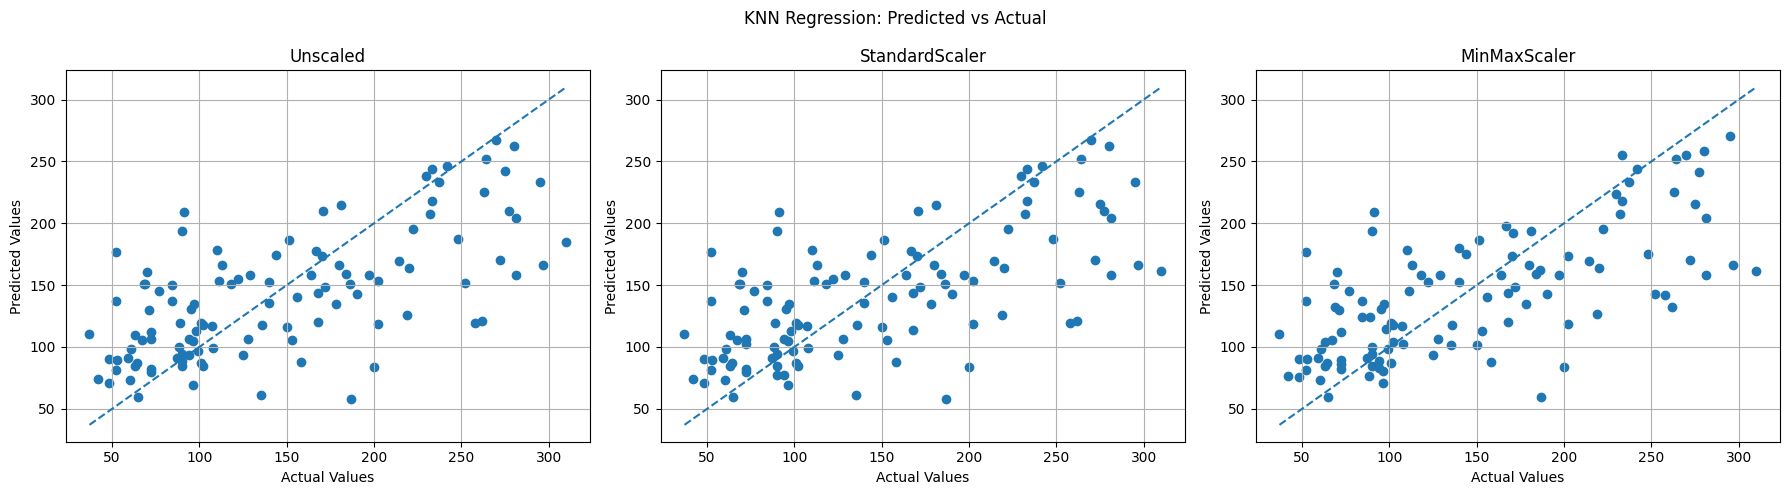

In [20]:
# Plot predicted vs actual values

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

predictions = {
    "Unscaled": y_pred_unscaled,
    "StandardScaler": y_pred_standard,
    "MinMaxScaler": y_pred_minmax
}

for ax, (method, predictions_values) in zip(
    axes,
    predictions.items()
):

    ax.scatter(
        y_diabetes_test,
        predictions_values
    )

    # Reference line: perfect prediction
    minimum = min(
        y_diabetes_test.min(),
        predictions_values.min()
    )

    maximum = max(
        y_diabetes_test.max(),
        predictions_values.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(f"{method}")
    ax.grid(True)

plt.suptitle("KNN Regression: Predicted vs Actual")
plt.tight_layout()

plt.show()

## Q7: KNN Regression - Scaling Impact

The Diabetes dataset contains 442 samples, 10 features, and a continuous target variable. The data was split into 75% training data and 25% testing data using random_state=42.

KNN regression was trained with k=5 using three different approaches: unscaled data, StandardScaler, and MinMaxScaler.

KNN is a distance-based algorithm, so feature scaling can affect which observations are considered neighbors. Without scaling, features with larger numerical ranges can have a greater influence on the distance calculation.

StandardScaler transforms the features so that they are centered around zero with approximately unit standard deviation. MinMaxScaler transforms the features into a common range.

The performance was evaluated using RMSE and R². Lower RMSE indicates smaller prediction errors, while a higher R² indicates that the model explains more of the variation in the target.

For this experiment, MinMaxScaler gives the lowest RMSE and the highest R² among the three approaches. The unscaled model does not necessarily fail completely because the features in the sklearn Diabetes dataset are already stored on relatively similar scales, but scaling still changes the neighborhood relationships and therefore the predictions.

Overall, scaling can be important for KNN regression because KNN relies on distances between observations.

In [21]:
# Q8: Regression Hyperparameter Tuning

k_values = [1, 3, 5, 7, 9, 11, 15, 20]

q8_results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_diabetes_train_standard, y_diabetes_train)

    y_train_pred = knn.predict(X_diabetes_train_standard)
    y_test_pred = knn.predict(X_diabetes_test_standard)

    train_rmse = np.sqrt(mean_squared_error(y_diabetes_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_diabetes_test, y_test_pred))

    train_r2 = r2_score(y_diabetes_train, y_train_pred)
    test_r2 = r2_score(y_diabetes_test, y_test_pred)

    q8_results.append({
        "k": k,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

q8_comparison = pd.DataFrame(q8_results)

display(q8_comparison.round(4))

,k,Train RMSE,Test RMSE,Train R²,Test R²
0,1,0.0000,76.2280,1.0000,-0.0508
1,3,47.6528,58.4743,0.6243,0.3817
2,5,51.0740,56.0799,0.5685,0.4313
3,7,53.6324,54.6738,0.5241,0.4594
4,9,54.2961,55.4799,0.5123,0.4434
5,11,54.8078,55.1517,0.5030,0.4499
6,15,55.4874,54.7856,0.4906,0.4572
7,20,56.0383,54.2480,0.4805,0.4678


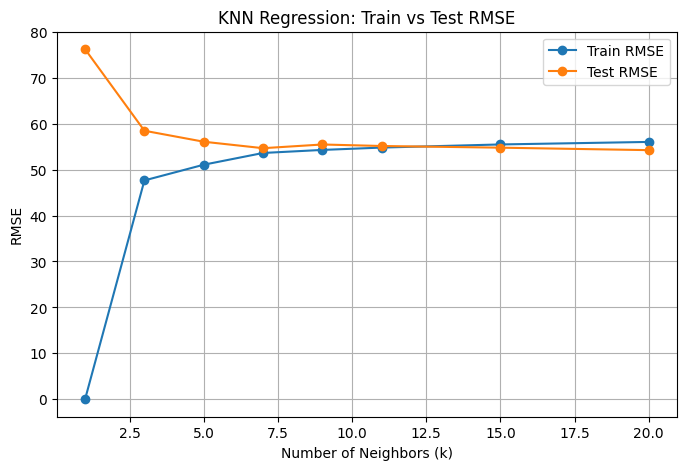

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    q8_comparison["k"],
    q8_comparison["Train RMSE"],
    marker="o",
    label="Train RMSE"
)

plt.plot(
    q8_comparison["k"],
    q8_comparison["Test RMSE"],
    marker="o",
    label="Test RMSE"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("RMSE")
plt.title("KNN Regression: Train vs Test RMSE")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
optimal_k = q8_comparison.loc[
    q8_comparison["Test RMSE"].idxmin(), "k"
]

optimal_test_rmse = q8_comparison["Test RMSE"].min()

print("Optimal k:", optimal_k)
print("Lowest Test RMSE:", round(optimal_test_rmse, 4))

Optimal k: 20
Lowest Test RMSE: 54.248


In [24]:
optimal_knn = KNeighborsRegressor(n_neighbors=optimal_k)

optimal_knn.fit(
    X_diabetes_train_standard,
    y_diabetes_train
)

y_optimal_pred = optimal_knn.predict(X_diabetes_test_standard)

residuals = y_diabetes_test - y_optimal_pred

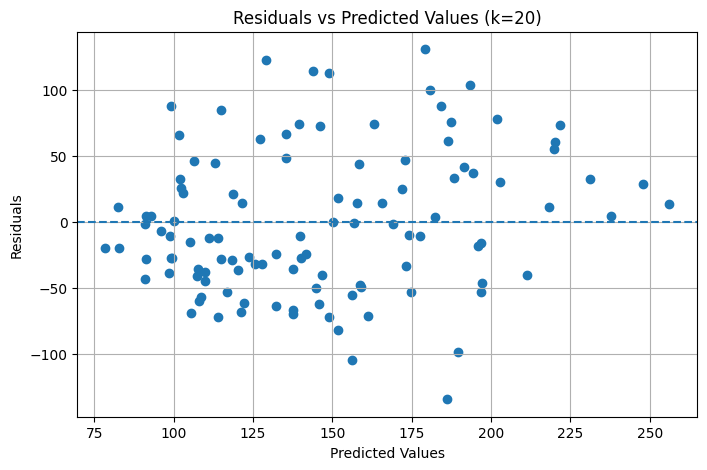

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(y_optimal_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residuals vs Predicted Values (k={optimal_k})")
plt.grid(True)
plt.show()

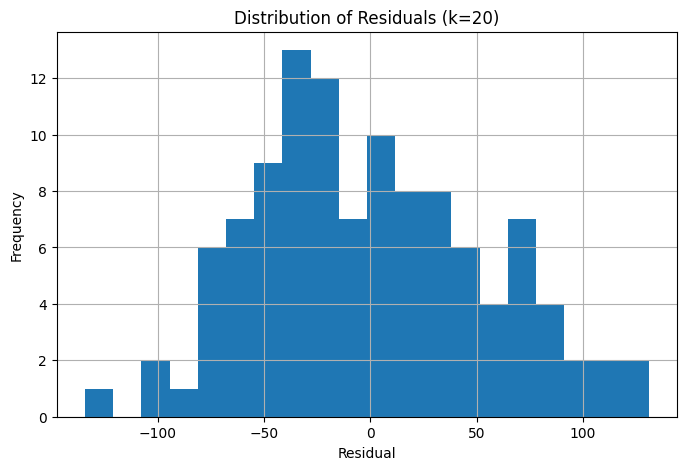

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Distribution of Residuals (k={optimal_k})")
plt.grid(True)
plt.show()

## Q8: Regression Hyperparameter Tuning

The optimal value of k is 20 because it gives the lowest test RMSE among the tested values.

For k=1, the training RMSE is 0 because each training sample is essentially its own nearest neighbor. However, the test RMSE is very high, showing strong overfitting.

As k increases, the predictions become smoother because more neighbors contribute to the prediction. This generally reduces overfitting, although very large values of k can eventually cause underfitting.

The residuals are calculated as:

Residual = Actual Value - Predicted Value

Ideally, residuals should be randomly scattered around zero without a clear pattern. A visible pattern or changing spread in the residual plot can indicate that the model is not capturing some structure in the data.

In this experiment, k=20 gives the best test RMSE and therefore provides the best performance among the tested k values.

In [27]:
# Q9: Distance Metrics & Weighting in Regression

distance_metrics = ["euclidean", "manhattan"]
weighting_methods = ["uniform", "distance"]

q9_results = []

for metric in distance_metrics:
    for weighting in weighting_methods:

        knn = KNeighborsRegressor(
            n_neighbors=7,
            metric=metric,
            weights=weighting
        )

        knn.fit(
            X_diabetes_train_standard,
            y_diabetes_train
        )

        y_pred = knn.predict(X_diabetes_test_standard)

        test_rmse = np.sqrt(
            mean_squared_error(y_diabetes_test, y_pred)
        )

        test_r2 = r2_score(
            y_diabetes_test,
            y_pred
        )

        weighting_name = (
            "Uniform"
            if weighting == "uniform"
            else "Inverse Distance"
        )

        q9_results.append({
            "Distance Metric": metric.capitalize(),
            "Weighting": weighting_name,
            "Test RMSE": test_rmse,
            "Test R²": test_r2
        })

q9_comparison = pd.DataFrame(q9_results)

display(q9_comparison.round(4))

,Distance Metric,Weighting,Test RMSE,Test R²
0,Euclidean,Uniform,54.6738,0.4594
1,Euclidean,Inverse Distance,54.5926,0.4610
2,Manhattan,Uniform,54.4850,0.4631
3,Manhattan,Inverse Distance,54.3606,0.4656


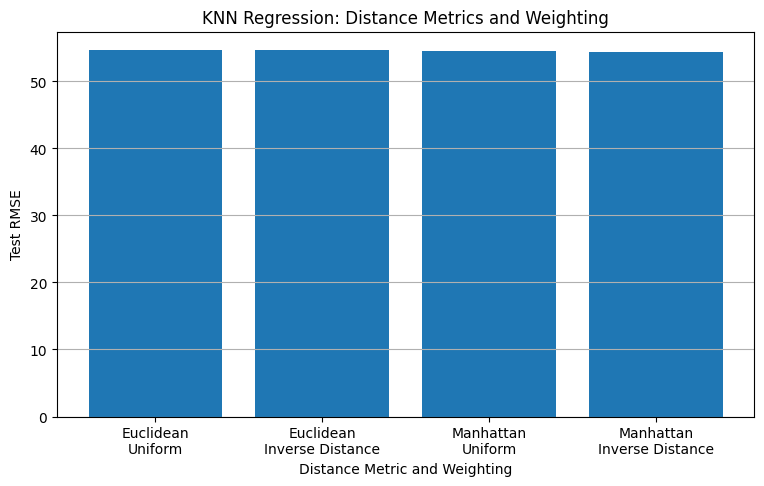

In [28]:
# Q9: Comparison of Test RMSE

plt.figure(figsize=(9, 5))

labels = [
    f"{row['Distance Metric']}\n{row['Weighting']}"
    for _, row in q9_comparison.iterrows()
]

plt.bar(labels, q9_comparison["Test RMSE"])

plt.xlabel("Distance Metric and Weighting")
plt.ylabel("Test RMSE")
plt.title("KNN Regression: Distance Metrics and Weighting")
plt.grid(True, axis="y")
plt.show()

## Q9: Distance Metrics & Weighting in Regression

The four combinations were compared using k=7 with StandardScaler.

Manhattan distance performed slightly better than Euclidean distance in this experiment, giving lower RMSE and higher R².

Inverse distance weighting gives greater importance to closer neighbors because their distance is used to determine their contribution. Uniform weighting gives every neighbor equal importance.

For both Euclidean and Manhattan distance, inverse distance weighting slightly improved the results compared with uniform weighting.

The best combination was Manhattan distance with inverse distance weighting. It achieved the lowest test RMSE of approximately 54.3606 and the highest R² of approximately 0.4656.

Therefore, for this particular train-test split, Manhattan distance combined with inverse distance weighting produced the best performance among the four tested KNN regression models.

## Q10: Data Leakage, Edge Cases & Practical Recommendations

In [29]:
# Q10(a): Data Leakage

# WRONG APPROACH:
# Scale the entire dataset before splitting
wine_scaler_wrong = StandardScaler()
X_wine_scaled_wrong = wine_scaler_wrong.fit_transform(wine.data)

X_train_wrong, X_test_wrong, y_train_wrong, y_test_wrong = train_test_split(
    X_wine_scaled_wrong,
    wine.target,
    test_size=0.25,
    stratify=wine.target,
    random_state=42
)

knn_wrong = KNeighborsClassifier(n_neighbors=5)
knn_wrong.fit(X_train_wrong, y_train_wrong)

wrong_accuracy = accuracy_score(
    y_test_wrong,
    knn_wrong.predict(X_test_wrong)
)


# CORRECT APPROACH:
# Split first, then fit scaler only on training data
X_train_correct, X_test_correct, y_train_correct, y_test_correct = train_test_split(
    wine.data,
    wine.target,
    test_size=0.25,
    stratify=wine.target,
    random_state=42
)

wine_scaler_correct = StandardScaler()

X_train_correct_scaled = wine_scaler_correct.fit_transform(X_train_correct)
X_test_correct_scaled = wine_scaler_correct.transform(X_test_correct)

knn_correct = KNeighborsClassifier(n_neighbors=5)
knn_correct.fit(X_train_correct_scaled, y_train_correct)

correct_accuracy = accuracy_score(
    y_test_correct,
    knn_correct.predict(X_test_correct_scaled)
)


leakage_comparison = pd.DataFrame({
    "Method": ["Wrong: Scale Before Split", "Correct: Split Before Scale"],
    "Test Accuracy": [wrong_accuracy, correct_accuracy]
})

display(leakage_comparison.round(4))

,Method,Test Accuracy
0,Wrong: Scale Before Split,0.9333
1,Correct: Split Before Scale,0.9333


### Data Leakage Explanation

In the wrong approach, the scaler is fitted using the complete dataset before the train-test split. Therefore, information from the test set is used while calculating the scaling parameters.

In the correct approach, the data is split first. The scaler is fitted only on the training data and then used to transform the test data.

In this experiment, both approaches produced the same test accuracy of approximately 0.9333. However, the wrong approach still represents data leakage because information from the test set was used during preprocessing.

The same accuracy does not mean that the wrong approach is correct.

In [30]:
# Q10(b1): Class Imbalance

from sklearn.datasets import make_classification

X_imbalance, y_imbalance = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    weights=[0.90, 0.10],
    random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imbalance,
    y_imbalance,
    test_size=0.25,
    stratify=y_imbalance,
    random_state=42
)

imbalance_scaler = StandardScaler()

X_train_imb_scaled = imbalance_scaler.fit_transform(X_train_imb)
X_test_imb_scaled = imbalance_scaler.transform(X_test_imb)

knn_imbalance = KNeighborsClassifier(n_neighbors=5)

knn_imbalance.fit(
    X_train_imb_scaled,
    y_train_imb
)

y_pred_imbalance = knn_imbalance.predict(
    X_test_imb_scaled
)

imbalance_accuracy = accuracy_score(
    y_test_imb,
    y_pred_imbalance
)

print("Accuracy:", round(imbalance_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_imb,
        y_pred_imbalance
    )
)

Accuracy: 0.972

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       224
           1       1.00      0.73      0.84        26

    accuracy                           0.97       250
   macro avg       0.98      0.87      0.91       250
weighted avg       0.97      0.97      0.97       250



### Class Imbalance Explanation

The synthetic dataset contains approximately 90% class 0 and 10% class 1.

The KNN model achieves an accuracy of approximately 97.2%, which appears high. However, accuracy alone can be misleading for imbalanced data because the majority class has many more samples.

The F1-score for class 0 is approximately 0.9846, while the F1-score for the minority class 1 is approximately 0.8444.

Therefore, per-class metrics are important because they show how well the model performs on each class instead of only showing the overall accuracy.

In [31]:
# Q10(b2): Effect of Outliers

# Clean Iris data
X_iris_clean_train, X_iris_clean_test, y_iris_clean_train, y_iris_clean_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.25,
    stratify=iris.target,
    random_state=42
)

iris_scaler_clean = StandardScaler()

X_iris_clean_train_scaled = iris_scaler_clean.fit_transform(
    X_iris_clean_train
)

X_iris_clean_test_scaled = iris_scaler_clean.transform(
    X_iris_clean_test
)


# Add 5 outliers to class 0
class_1_mean = iris.data[iris.target == 1].mean(axis=0)

iris_outliers = np.tile(
    class_1_mean,
    (5, 1)
)

iris_outlier_labels = np.zeros(5, dtype=int)

X_iris_contaminated = np.vstack([
    iris.data,
    iris_outliers
])

y_iris_contaminated = np.concatenate([
    iris.target,
    iris_outlier_labels
])


# Split contaminated dataset
X_cont_train, X_cont_test, y_cont_train, y_cont_test = train_test_split(
    X_iris_contaminated,
    y_iris_contaminated,
    test_size=0.25,
    stratify=y_iris_contaminated,
    random_state=42
)

iris_scaler_cont = StandardScaler()

X_cont_train_scaled = iris_scaler_cont.fit_transform(
    X_cont_train
)

X_cont_test_scaled = iris_scaler_cont.transform(
    X_cont_test
)


# Compare k=3 and k=5
outlier_results = []

for k in [3, 5]:

    # Clean model
    clean_model = KNeighborsClassifier(n_neighbors=k)
    clean_model.fit(
        X_iris_clean_train_scaled,
        y_iris_clean_train
    )

    clean_accuracy = accuracy_score(
        y_iris_clean_test,
        clean_model.predict(X_iris_clean_test_scaled)
    )


    # Contaminated model
    contaminated_model = KNeighborsClassifier(n_neighbors=k)
    contaminated_model.fit(
        X_cont_train_scaled,
        y_cont_train
    )

    contaminated_accuracy = accuracy_score(
        y_cont_test,
        contaminated_model.predict(X_cont_test_scaled)
    )


    accuracy_change = contaminated_accuracy - clean_accuracy

    outlier_results.append({
        "k": k,
        "Clean Accuracy": clean_accuracy,
        "Contaminated Accuracy": contaminated_accuracy,
        "Change in Accuracy": accuracy_change
    })


outlier_comparison = pd.DataFrame(outlier_results)

display(outlier_comparison.round(4))

,k,Clean Accuracy,Contaminated Accuracy,Change in Accuracy
0,3,0.9211,0.8974,-0.0236
1,5,0.9211,0.8974,-0.0236


### Outlier Explanation

Five outliers were added to class 0 in a region corresponding to the feature mean of class 1. The clean and contaminated datasets were evaluated using k=3 and k=5.

For both k values, the clean accuracy was approximately 92.11%, while the contaminated accuracy was approximately 89.74%.

Therefore, the accuracy decreased by approximately 2.36 percentage points after adding the outliers.

This shows that KNN can be affected by outliers because KNN makes predictions using distances to neighboring points. Outliers can change the local neighborhood structure and therefore affect classification.